# Chapter 4: Training Models

## 1. Linear Regression Model

In [1]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

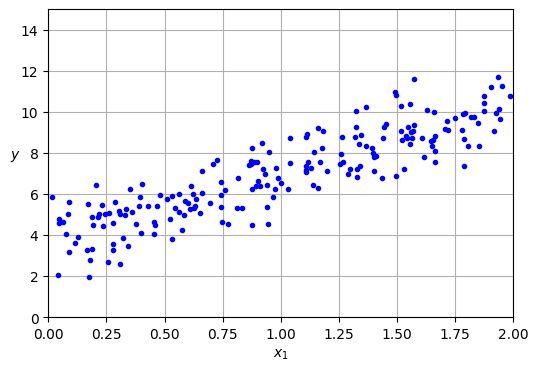

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.axis([0, 2, 0, 15])
plt.show()

In [5]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.69084138],
       [3.32960458]])

In [6]:
# Making new predictions with the best theta
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

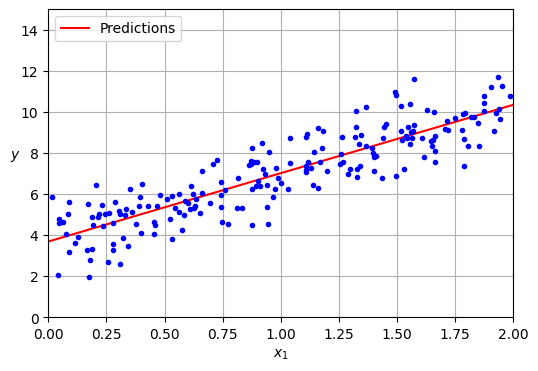

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label='Predictions')
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc='upper left')
plt.show()

In [11]:
# Now implementing Linear Regression with Scikit-Learn
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

.intercept_ is bias term and .coef_ are feature weights.

In [12]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

LinearRegression is based on lstsq, which "least squares" 

In [14]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.69084138],
       [3.32960458]])

$\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^+$ is the pseudo inverse of X

In [15]:
np.linalg.pinv(X_b) @ y

array([[3.69084138],
       [3.32960458]])

## 2. Batch Gradient Descent

In [16]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b) # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

In [20]:
for _ in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta -  y)
    theta = theta - eta * gradients

In [21]:
theta

array([[3.69084138],
       [3.32960458]])